 # Forced Duffing Oscillator (Chaotic)

In [235]:
# import all the necessary libraries
import pysindy as ps
import numpy as np

from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error

In [236]:
# The Duffing oscillator system
def duffing(t, x, delta=0.2, alpha=1, beta=-1, gamma=0.3, omega=1):
    return [x[1], 
           -beta * x[0] - delta * x[1] - alpha * x[0] ** 3 + gamma * np.cos(x[2]),
           omega]

In [237]:
# generate the data for testing
start = 0
end = 100
step = 0.01
t_span = [start, end]
x0 = [0.3, 0.1, 0]
sol = solve_ivp(duffing, t_span, x0, dense_output=True)
t = np.arange(start, end+step/10, step)
x = sol.sol(t).T

In [238]:
# The feature names of the columns of y
feature_names = ['x1', 'x2', 'omega t']

# Which feature library to use
# Here I'm using a polynomial library that contains all combinations of the columns upto the degree 3
feature_library = ps.PolynomialLibrary(degree=3)+ ps.FourierLibrary()


# functions = [lambda x : x, lambda x: x**3]
# function_names = [lambda x : str(x), lambda x: str(x) + "^3"]
# lib_custom = CustomLibrary(library_functions=functions, 
#                            function_names=function_names)
# lib_custom.fit(x)
# lib_custom.transform(x)

# Differentiation method
differentiation_method = ps.SmoothedFiniteDifference(order=2)

# Optimizer
# opt = ps.SR3(threshold=0.2,thresholder='L0',max_iter=100)
opt = ps.STLSQ(threshold=0.05)

# Building the model
model=ps.SINDy(differentiation_method=differentiation_method,
               feature_library = feature_library,
               feature_names=feature_names, 
              optimizer=opt)

# Fitting the model to the training data
model.fit(x,t=t)

# Print the model
model.print()

(x1)' = 1.013 x2 + -0.001 x2^3 + -0.013 sin(1 x2)
(x2)' = 0.596 x1 + -0.198 x2 + -0.936 x1^3 + 0.405 sin(1 x1) + 0.299 cos(1 omega t)
(omega t)' = 1.000 1


In [239]:
# Simulate the identified system 
sim = model.simulate(x0,t=t) 

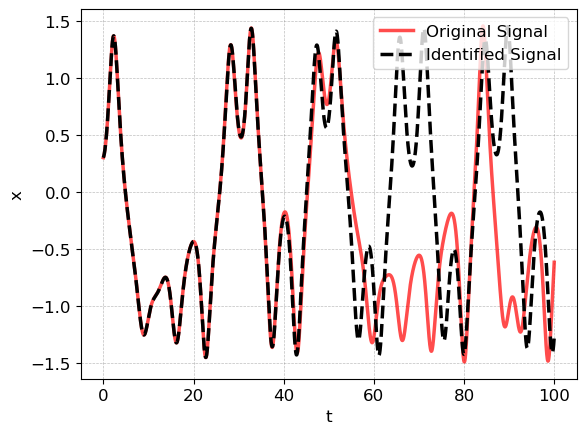

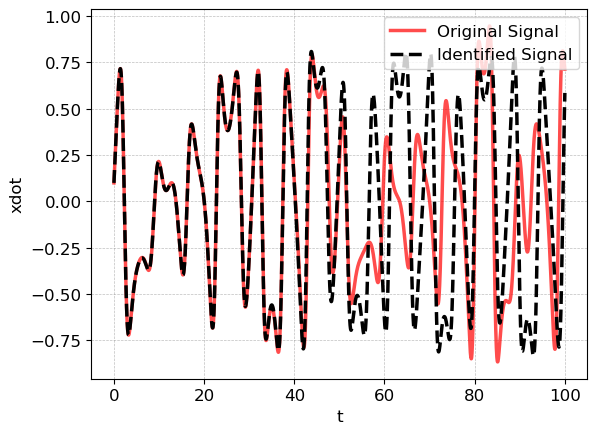

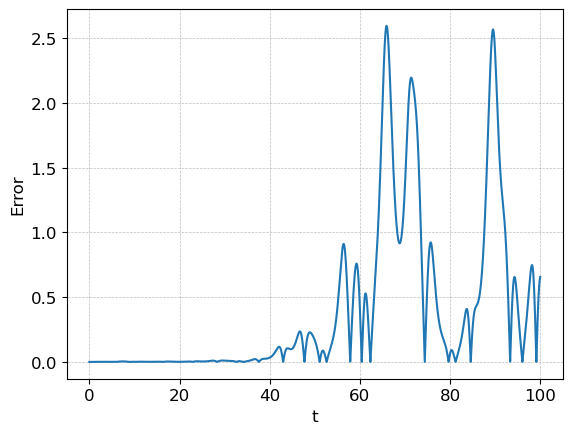

In [240]:
# plot the solution

plt.rcParams.update({'font.size': 12})

# displacement
plt.plot(t,x[:,0],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,0],'k--', alpha=1,linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("x")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('disp_duffing_f.pdf', format='pdf', dpi=300)
plt.show()

# velocity
plt.plot(t,x[:,1],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,1],'k--',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("xdot")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('vel_duffing_f.pdf', format='pdf', dpi=300)
plt.show()

# Error
plt.plot(t, np.abs(sim[:,0]-x[:,0]))
plt.xlabel("t")
plt.ylabel("Error")
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('error_duffing_f.pdf', format='pdf', dpi=300)
plt.show()


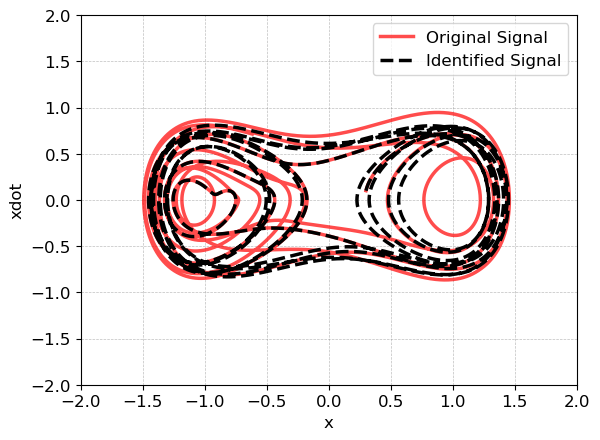

In [241]:
# velocity
plt.plot(x[:,0],x[:,1],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(sim[:,0],sim[:,1],'k--',linewidth=2.5,label="Identified Signal")
plt.xlabel("x")
plt.ylabel("xdot")
plt.xlim((-2,2))
plt.ylim((-2,2))
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('pp_duffing.pdf', format='pdf', dpi=300)
plt.show()

In [242]:
R2 = r2_score(x[:,0],sim[:,0])
MSE = mean_squared_error(x[:,0],sim[:,0])

print(f"R2 score: {R2}")
print(f"Mean Squared Error: {MSE}")

R2 score: 0.1786608732777969
Mean Squared Error: 0.5391391310608872


In [243]:
print(x)

[[ 3.00000000e-01  1.00000000e-01  0.00000000e+00]
 [ 3.01027644e-01  1.05528135e-01  1.00000000e-02]
 [ 3.02110550e-01  1.11052602e-01  2.00000000e-02]
 ...
 [-6.32205229e-01  7.19039352e-01  9.99800000e+01]
 [-6.25028428e-01  7.16365680e-01  9.99900000e+01]
 [-6.17878192e-01  7.13700532e-01  1.00000000e+02]]
